In [ ]:
# Setup: change working directory to project root so all relative paths work
import os
from pathlib import Path

# Notebooks live in <project_root>/notebooks/, so go up one level
project_root = str(Path(os.getcwd()).parent) if Path(os.getcwd()).name == "notebooks" else os.getcwd()
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression


def detect_columns(df):
    cols = [c.lower() for c in df.columns]
    if "log10_target" in cols and "log10_predict" in cols:
        return "log10_target", "log10_predict"
    else:
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) >= 2:
            return num_cols[0], num_cols[1]
        else:
            raise ValueError("Could not detect target/predict columns in file")


def compute_metrics(df, target_col, pred_col, dataset_name="Dataset"):
    y_true = df[target_col].values
    y_pred = df[pred_col].values
    errors = y_pred - y_true

    mbe = np.mean(errors)  
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    se_mbe = np.std(errors, ddof=1) / np.sqrt(len(errors))  
    r2 = r2_score(y_true, y_pred)
    std_error = np.std(errors, ddof=1)  
    mean_target = np.mean(y_true)
    mean_pred = np.mean(y_pred)

    return {
        "Dataset": dataset_name,
        "N": len(df),
        "MBE (dex)": mbe,
        "RMSE (dex)": rmse,
        "MAE (dex)": mae,
        "SE of MBE": se_mbe,
        "R²": r2,
        "Std. Deviation of Errors": std_error,
        "Mean Target": mean_target,
        "Mean Predicted": mean_pred
    }, errors, y_true, y_pred

# --- data ---
files = {
    "Dataset A": "data/raw/Sendek_OP.csv",
    "Dataset B": "data/raw/LLZO_OP.csv",
    "Dataset C": "data/raw/LiIon_OP.csv"
}

results = []
all_errors = {}
all_true = {}
all_pred = {}

# --- Process each file ---
for name, file in files.items():
    df = pd.read_csv(file)
    target_col, pred_col = detect_columns(df)
    metrics, errors, y_true, y_pred = compute_metrics(df, target_col, pred_col, dataset_name=name)
    results.append(metrics)
    all_errors[name] = errors
    all_true[name] = y_true
    all_pred[name] = y_pred

# --- Save summary ---
summary_df = pd.DataFrame(results).round(3)
output_path = "docs/error_summaries/model_error_summary_cleanplots.xlsx"
summary_df.to_excel(output_path, index=False)
print("Metrics saved to:", output_path)
print(summary_df)

PermissionError: [Errno 13] Permission denied: 'model_error_summary_cleanplots.xlsx'

Saved Parity Plot to: acs_plots/parity_plot_acs.png


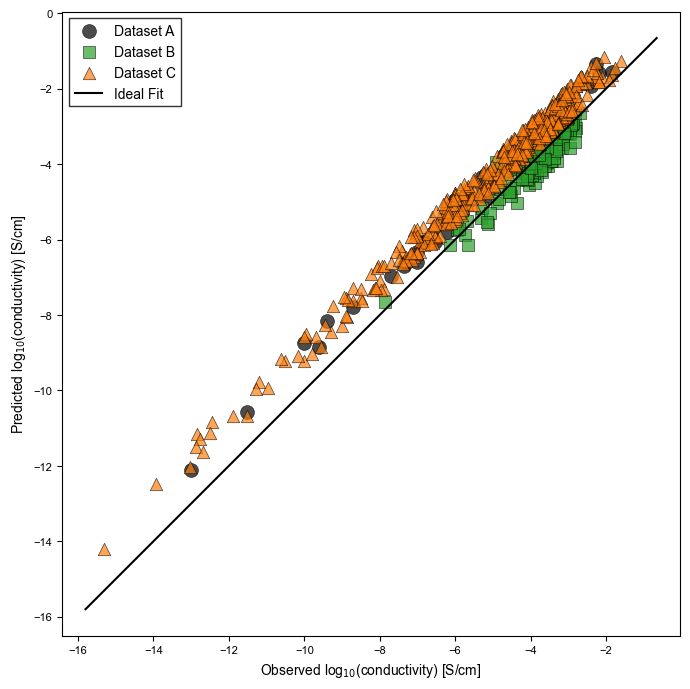

In [17]:
# --- Combined Parity Plot (ACS-compatible) ---
plt.figure(figsize=(7, 7))

# Color scheme (kept consistent) + marker styles for B/W compatibility
datasets = {
    "Dataset A": {"color": "black", "marker": "o", "size": 100},
    "Dataset B": {"color": "#2ca02c", "marker": "s", "size": 80},
    "Dataset C": {"color": "#ff7f0e", "marker": "^", "size": 80}
}

# Plot each dataset with distinct markers for B/W compatibility
for name in files.keys():
    plt.scatter(all_true[name], all_pred[name], 
                s=datasets[name]["size"], 
                alpha=0.7,
                c=datasets[name]["color"], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# --- 1:1 line ---
lims = [min([all_true[k].min() for k in files]+[all_pred[k].min() for k in files])-0.5,
        max([all_true[k].max() for k in files]+[all_pred[k].max() for k in files])+0.5]
plt.plot(lims, lims, 'k-', lw=1.5, label="Ideal Fit")

# Labels and formatting
plt.xlabel("Observed log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Predicted log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

# Equal aspect ratio for parity plot
plt.axis("equal")
plt.tight_layout()

# Save with high resolution
parity_path = "outputs/acs_plots/parity_plot_acs.png"
plt.savefig(parity_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Parity Plot to:", parity_path)
plt.show()


Saved Parity Plot (Log Scale) to: acs_plots/parity_plot_logscale_acs.png


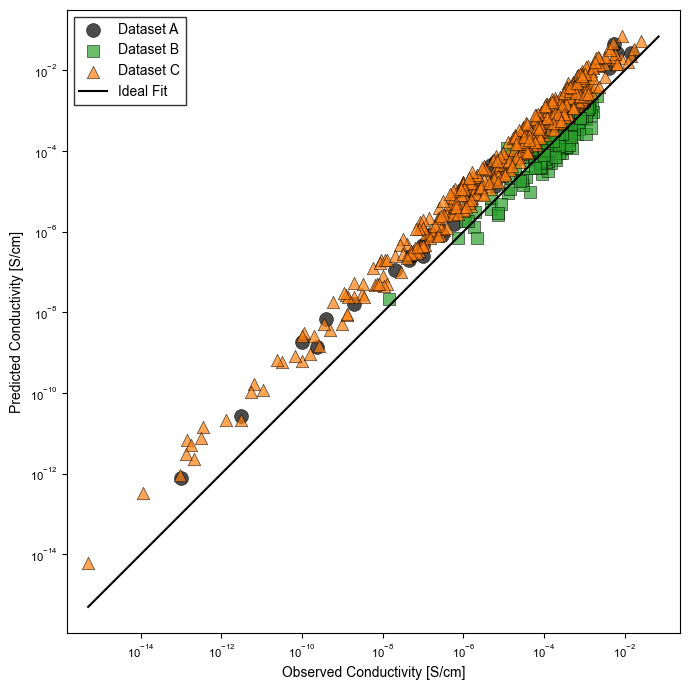

In [18]:
# --- Combined Parity Plot with Log Scale Axes (ACS-compatible) ---
plt.figure(figsize=(7, 7))

# Color scheme (kept consistent) + marker styles for B/W compatibility
datasets = {
    "Dataset A": {"color": "black", "marker": "o", "size": 100},
    "Dataset B": {"color": "#2ca02c", "marker": "s", "size": 80},
    "Dataset C": {"color": "#ff7f0e", "marker": "^", "size": 80}
}

# Convert log values to actual conductivity values
all_true_actual = {name: 10**all_true[name] for name in files.keys()}
all_pred_actual = {name: 10**all_pred[name] for name in files.keys()}

# Plot each dataset with distinct markers for B/W compatibility
for name in files.keys():
    plt.scatter(all_true_actual[name], all_pred_actual[name], 
                s=datasets[name]["size"], 
                alpha=0.7,
                c=datasets[name]["color"], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Set logarithmic scales
plt.xscale('log')
plt.yscale('log')

# --- 1:1 line ---
# Calculate limits in actual values
lims = [min([all_true_actual[k].min() for k in files]+[all_pred_actual[k].min() for k in files]),
        max([all_true_actual[k].max() for k in files]+[all_pred_actual[k].max() for k in files])]
plt.plot(lims, lims, 'k-', lw=1.5, label="Ideal Fit")

# Labels and formatting
plt.xlabel("Observed Conductivity [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Predicted Conductivity [S/cm]", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

# Equal aspect ratio for parity plot (in log space)
plt.axis("equal")
plt.tight_layout()

# Save with high resolution
parity_path_logscale = "outputs/acs_plots/parity_plot_logscale_acs.png"
plt.savefig(parity_path_logscale, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Parity Plot (Log Scale) to:", parity_path_logscale)
plt.show()


Saved Residual Distribution Plot to: acs_plots/residual_distribution_acs.png


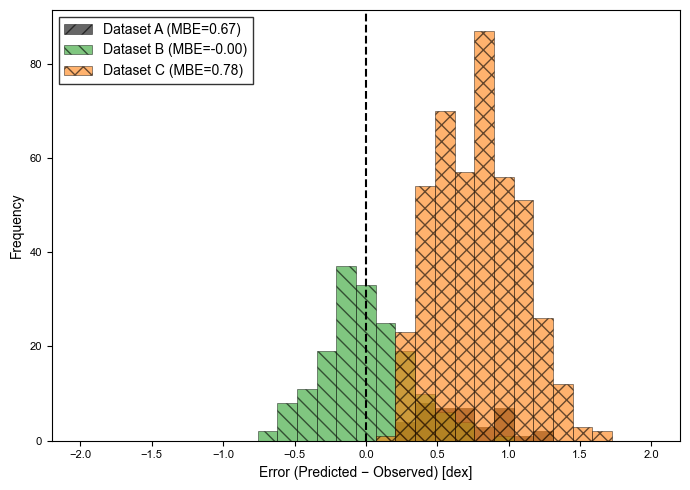

In [19]:
# --- Combined Residual Histogram (ACS-compatible) ---
plt.figure(figsize=(7, 5))
bins = np.linspace(-2, 2, 30)

# Hatching patterns for B/W compatibility
colors = {"Dataset A": "black", "Dataset B": "#2ca02c", "Dataset C": "#ff7f0e"}
hatches = {"Dataset A": "//", "Dataset B": "\\\\", "Dataset C": "xx"}

for name in files.keys():
    plt.hist(all_errors[name], bins=bins, 
             alpha=0.6,
             label=f"{name} (MBE={np.mean(all_errors[name]):.2f})", 
             color=colors[name],
             edgecolor='black',
             linewidth=0.5,
             hatch=hatches[name])

# Zero reference line
plt.axvline(0, color='k', linestyle='--', linewidth=1.5)

# Labels and formatting
plt.xlabel("Error (Predicted − Observed) [dex]", fontsize=10, fontname='Arial')
plt.ylabel("Frequency", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()

# Save with high resolution
residuals_path = "outputs/acs_plots/residual_distribution_acs.png"
plt.savefig(residuals_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Residual Distribution Plot to:", residuals_path)
plt.show()


Saved Residuals vs Predicted Plot to: acs_plots/residuals_vs_predicted_acs.png


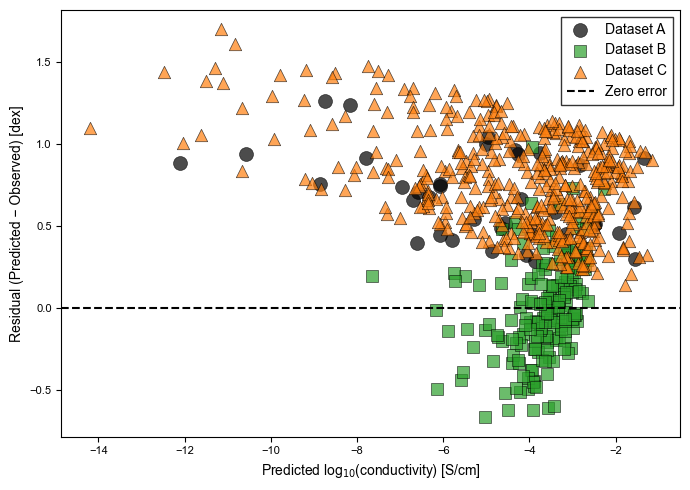

In [20]:
# --- Residuals vs Predicted Plot (ACS-compatible) ---
plt.figure(figsize=(7, 5))

# Use same marker styles as parity plot for consistency
for name in files.keys():
    plt.scatter(all_pred[name], all_errors[name], 
                alpha=0.7, 
                s=datasets[name]["size"],
                c=colors[name], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Zero error reference line
plt.axhline(0, color='k', linestyle='--', linewidth=1.5, label="Zero error")

# Labels and formatting
plt.xlabel("Predicted log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Residual (Predicted − Observed) [dex]", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()

# Save with high resolution
residual_vs_pred_path = "outputs/acs_plots/residuals_vs_predicted_acs.png"
plt.savefig(residual_vs_pred_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Residuals vs Predicted Plot to:", residual_vs_pred_path)
plt.show()


Saved Residuals vs Observed Plot (Log Scale) to: acs_plots/residuals_vs_observed_logscale_acs.png


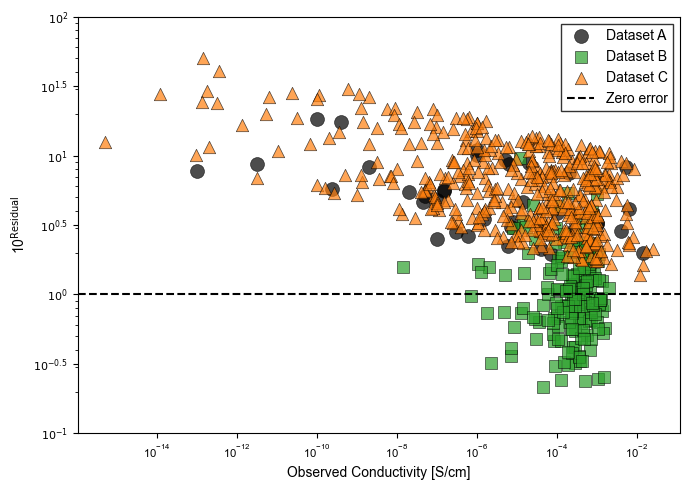

In [21]:
# log_pred - log_target vs log_target plot but show a log scale on x-axis and y-axis
plt.figure(figsize=(7, 5))
for name in files.keys():
    log_target = all_true[name]
    log_pred = all_pred[name]
    residuals = log_pred - log_target
    plt.scatter(10**log_target, 10**residuals, 
                alpha=0.7, 
                s=datasets[name]["size"],
                c=colors[name], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Zero error reference line
plt.axhline(1, color='k', linestyle='--', linewidth=1.5, label="Zero error")
plt.xscale('log')
plt.yscale('log')

# Add more y-axis tick labels
plt.yticks([10**i for i in np.arange(-1, 2.5, 0.5)], 
           [f'$10^{{{i:.1f}}}$' if i != int(i) else f'$10^{{{int(i)}}}$' 
            for i in np.arange(-1, 2.5, 0.5)], 
           fontsize=8, fontname='Arial')

plt.xlabel("Observed Conductivity [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("10$^{{\mathrm{{Residual}}}}$", fontsize=10, fontname='Arial')
plt.xticks(fontsize=8, fontname='Arial')
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})
plt.tight_layout()

# Save with high resolution
residual_vs_obs_path = "outputs/acs_plots/residuals_vs_observed_logscale_acs.png"
plt.savefig(residual_vs_obs_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Residuals vs Observed Plot (Log Scale) to:", residual_vs_obs_path)
plt.show()

Saved Residuals vs Observed Plot to: acs_plots/residuals_vs_observed_acs.png


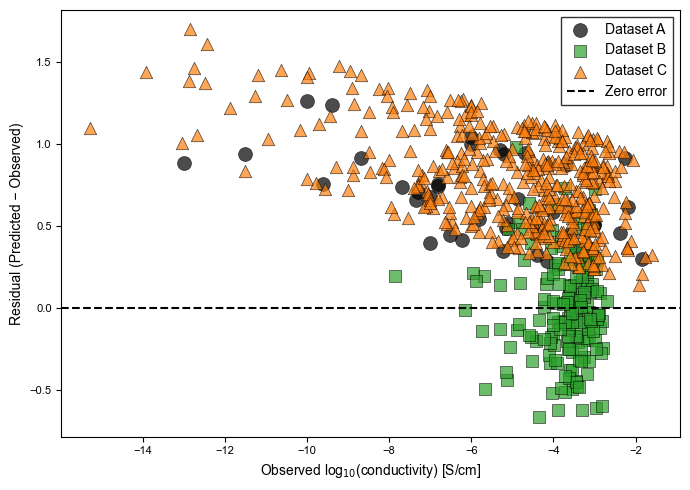

In [22]:
# --- Residuals vs Observed Plot (ACS-compatible) ---
plt.figure(figsize=(7, 5))

# Use same marker styles as parity plot for consistency
for name in files.keys():
    plt.scatter(all_true[name], all_errors[name], 
                alpha=0.7, 
                s=datasets[name]["size"],
                c=colors[name], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Zero error reference line
plt.axhline(0, color='k', linestyle='--', linewidth=1.5, label="Zero error")

# Labels and formatting
plt.xlabel("Observed log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Residual (Predicted − Observed)", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()

# Save with high resolution
residual_vs_pred_path = "outputs/acs_plots/residuals_vs_observed_acs.png"
plt.savefig(residual_vs_pred_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Residuals vs Observed Plot to:", residual_vs_pred_path)
plt.show()


Saved Normalized Residuals vs Predicted Plot to: acs_plots/normalized_residuals_vs_predicted_acs.png


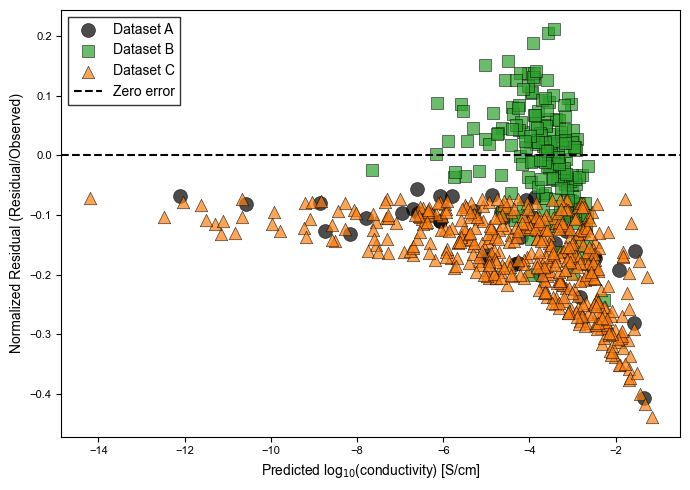

In [23]:
# --- Normalized Residuals vs Predicted Plot (ACS-compatible) ---
plt.figure(figsize=(7, 5))

# Calculate normalized residuals (residual/actual)
all_normalized_errors = {}
for name in files.keys():
    all_normalized_errors[name] = all_errors[name] / all_true[name]

# Use same marker styles as parity plot for consistency
for name in files.keys():
    plt.scatter(all_pred[name], all_normalized_errors[name], 
                alpha=0.7, 
                s=datasets[name]["size"],
                c=colors[name], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Zero error reference line
plt.axhline(0, color='k', linestyle='--', linewidth=1.5, label="Zero error")

# Labels and formatting
plt.xlabel("Predicted log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Normalized Residual (Residual/Observed)", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()

# Save with high resolution
normalized_residual_path = "outputs/acs_plots/normalized_residuals_vs_predicted_acs.png"
plt.savefig(normalized_residual_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Normalized Residuals vs Predicted Plot to:", normalized_residual_path)
plt.show()


Saved Normalized Residuals vs Actual Plot to: acs_plots/normalized_residuals_vs_actual_acs.png


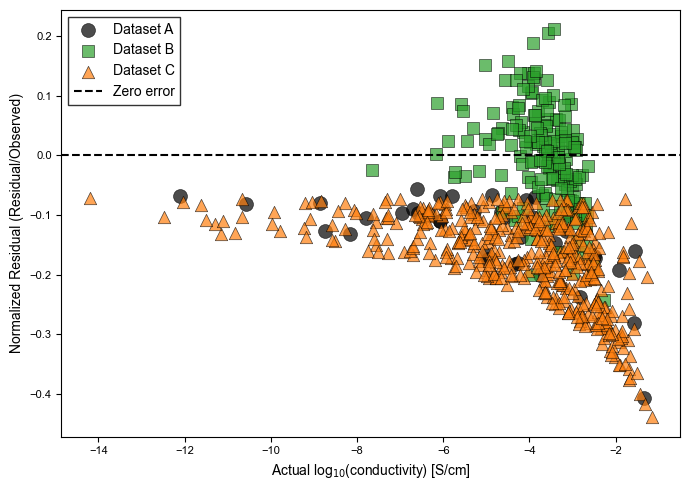

In [24]:
# --- Normalized Residuals vs Predicted Plot (ACS-compatible) ---
plt.figure(figsize=(7, 5))

# Calculate normalized residuals (residual/actual)
all_normalized_errors = {}
for name in files.keys():
    all_normalized_errors[name] = all_errors[name] / all_true[name]

# Use same marker styles as parity plot for consistency
for name in files.keys():
    plt.scatter(all_pred[name], all_normalized_errors[name], 
                alpha=0.7, 
                s=datasets[name]["size"],
                c=colors[name], 
                marker=datasets[name]["marker"],
                edgecolors='black',
                linewidths=0.5,
                label=name)

# Zero error reference line
plt.axhline(0, color='k', linestyle='--', linewidth=1.5, label="Zero error")

# Labels and formatting
plt.xlabel("Actual log$_{10}$(conductivity) [S/cm]", fontsize=10, fontname='Arial')
plt.ylabel("Normalized Residual (Residual/Observed)", fontsize=10, fontname='Arial')

# Legend with ACS-compatible font
plt.legend(frameon=True, fancybox=False, edgecolor='black', 
           fontsize=9, loc='best', prop={'family': 'Arial'})

# Set tick label font
plt.xticks(fontsize=8, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()

# Save with high resolution
normalized_residual_path = "outputs/acs_plots/normalized_residuals_vs_actual_acs.png"
plt.savefig(normalized_residual_path, dpi=600, bbox_inches="tight", facecolor='white')
print("Saved Normalized Residuals vs Actual Plot to:", normalized_residual_path)
plt.show()


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from datetime import datetime
import scipy.stats as stats

# --- Date tag ---
date_tag = "14sep"   

def detect_columns(df):
    cols = [c.lower() for c in df.columns]
    if "log10_target" in cols and "log10_predict" in cols:
        return "log10_target", "log10_predict"
    elif "target" in cols and "predict" in cols:
        return "target", "predict"
    else:
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) >= 2:
            return num_cols[0], num_cols[1]
        else:
            raise ValueError("Could not detect target/predict columns in file")


def compute_metrics(y_true, y_pred, dataset_name="Dataset"):
    errors = y_pred - y_true
    mbe = np.mean(errors)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE as percentage (handle zeros carefully)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100.0
    se_mbe = np.std(errors, ddof=1) / np.sqrt(len(errors))
    r2 = r2_score(y_true, y_pred)
    std_error = np.std(errors, ddof=1)
    mean_target = np.mean(y_true)
    mean_pred = np.mean(y_pred)

    return {
        "Dataset": dataset_name,
        "N": len(y_true),
        "MBE (dex)": mbe,
        "RMSE (dex)": rmse,
        "MAE (dex)": mae,
        "MAPE (%)": mape,
        "SE of MBE": se_mbe,
        "R²": r2,
        "Std. Deviation of Errors": std_error,
        "Mean Target": mean_target,
        "Mean Predicted": mean_pred
    }, errors

# --- data ---
files = {
    "Dataset A": "data/raw/Sendek_OP.csv",
    "Dataset B": "data/raw/LLZO_OP.csv",
    "Dataset C": "data/raw/LiIon_OP.csv"
}

results = []
all_errors = {}
all_true = {}
all_pred = {}

# --- datasets ---
for name, file in files.items():
    df = pd.read_csv(file)
    target_col, pred_col = detect_columns(df)
    y_true = df[target_col].values
    y_pred = df[pred_col].values
    metrics, errors = compute_metrics(y_true, y_pred, dataset_name=name)
    results.append(metrics)
    all_errors[name] = errors
    all_true[name] = y_true
    all_pred[name] = y_pred

# --- Combine all datasets for overall metrics ---
all_true_concat = np.concatenate(list(all_true.values()))
all_pred_concat = np.concatenate(list(all_pred.values()))
overall_metrics, overall_errors = compute_metrics(all_true_concat, all_pred_concat, dataset_name="Overall")
results.append(overall_metrics)

# --- Save summary with MAPE included ---
summary_df = pd.DataFrame(results).round(3)
output_path = f"docs/error_summaries/model_error_summary_with_mape_{date_tag}.xlsx"
summary_df.to_excel(output_path, index=False)
print("Metrics (including MAPE) saved to:", output_path)
print(summary_df)

colors = {"Dataset A":"black", "Dataset B":"#2ca02c", "Dataset C":"#ff7f0e"}


Metrics (including MAPE) saved to: model_error_summary_with_mape_14sep.xlsx
     Dataset    N  MBE (dex)  RMSE (dex)  MAE (dex)  MAPE (%)  SE of MBE  \
0  Dataset A   39      0.665       0.715      0.665    13.103      0.043   
1  Dataset B  175     -0.004       0.300      0.237     6.480      0.023   
2  Dataset C  442      0.782       0.834      0.782    17.040      0.014   
3    Overall  656      0.565       0.724      0.630    13.989      0.018   

      R²  Std. Deviation of Errors  Mean Target  Mean Predicted  
0  0.922                     0.266       -5.742          -5.077  
1  0.844                     0.301       -3.732          -3.735  
2  0.863                     0.292       -5.036          -4.254  
3  0.880                     0.452       -4.730          -4.164  


In [ ]:
# compute metrics for true<-5 and true>=-5 separately
for threshold in [-5]:
    results_threshold = []
    for name in files.keys():
        y_true = all_true[name]
        y_pred = all_pred[name]
        mask_below = y_true < threshold
        mask_above = y_true >= threshold

        # Below threshold
        if np.sum(mask_below) > 0:
            metrics_below, _ = compute_metrics(y_true[mask_below], y_pred[mask_below], dataset_name=f"{name} (true<{threshold})")
            results_threshold.append(metrics_below)

        # Above threshold
        if np.sum(mask_above) > 0:
            metrics_above, _ = compute_metrics(y_true[mask_above], y_pred[mask_above], dataset_name=f"{name} (true>={threshold})")
            results_threshold.append(metrics_above)

    # Overall metrics for below and above threshold
    mask_below_all = all_true_concat < threshold
    mask_above_all = all_true_concat >= threshold

    if np.sum(mask_below_all) > 0:
        overall_below_metrics, _ = compute_metrics(all_true_concat[mask_below_all], all_pred_concat[mask_below_all], dataset_name=f"Overall (true<{threshold})")
        results_threshold.append(overall_below_metrics)

    if np.sum(mask_above_all) > 0:
        overall_above_metrics, _ = compute_metrics(all_true_concat[mask_above_all], all_pred_concat[mask_above_all], dataset_name=f"Overall (true>={threshold})")
        results_threshold.append(overall_above_metrics)

    # Save thresholded summary
    summary_threshold_df = pd.DataFrame(results_threshold).round(3)
    threshold_output_path = f"docs/error_summaries/model_error_summary_threshold_{threshold}_{date_tag}.xlsx"
    summary_threshold_df.to_excel(threshold_output_path, index=False)
    print(f"Metrics for threshold {threshold} saved to:", threshold_output_path)
    print(summary_threshold_df)

Metrics for threshold -5 saved to: model_error_summary_threshold_-5_14sep.xlsx
                Dataset    N  MBE (dex)  RMSE (dex)  MAE (dex)  MAPE (%)  \
0   Dataset A (true<-5)   23      0.757       0.798      0.757    10.636   
1  Dataset A (true>=-5)   16      0.534       0.575      0.534    16.650   
2   Dataset B (true<-5)   13     -0.034       0.288      0.248     4.529   
3  Dataset B (true>=-5)  162     -0.001       0.301      0.236     6.636   
4   Dataset C (true<-5)  172      0.931       0.975      0.931    13.181   
5  Dataset C (true>=-5)  270      0.687       0.731      0.687    19.498   
6     Overall (true<-5)  208      0.852       0.928      0.869    12.359   
7    Overall (true>=-5)  448      0.432       0.606      0.518    14.746   

   SE of MBE     R²  Std. Deviation of Errors  Mean Target  Mean Predicted  
0      0.054  0.853                     0.259       -7.338          -6.581  
1      0.055  0.603                     0.222       -3.449          -2.916  
2    

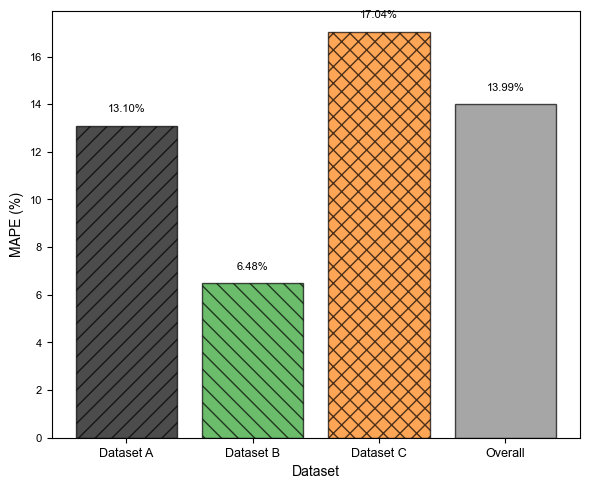

 MAPE bar plot saved to: acs_plots/mape_barplot_acs.png


In [27]:
# -----------------------
# MAPE Bar Plot (ACS-compatible)
# -----------------------
plt.figure(figsize=(6, 5))

datasets = summary_df["Dataset"]
mape_values = summary_df["MAPE (%)"]

# Hatching patterns for B/W compatibility (same as histogram)
hatches = {"Dataset A": "//", "Dataset B": "\\\\", "Dataset C": "xx"}

# Create bars with hatching
bars = plt.bar(datasets, mape_values, 
               color=[colors.get(d, "gray") for d in datasets], 
               edgecolor='black', 
               linewidth=1.0,
               alpha=0.7,
               hatch=[hatches.get(d, "") for d in datasets])

# Labels and formatting
plt.ylabel("MAPE (%)", fontsize=10, fontname='Arial')
plt.xlabel("Dataset", fontsize=10, fontname='Arial')

# Add value labels on top of bars
for i, v in enumerate(mape_values):
    plt.text(i, v + 0.5, f"{v:.2f}%", 
             ha='center', va='bottom', 
             fontsize=8, fontname='Arial')

# Set tick label font
plt.xticks(fontsize=9, fontname='Arial')
plt.yticks(fontsize=8, fontname='Arial')

plt.tight_layout()
# Save with high resolution
mape_plot_path = f"outputs/acs_plots/mape_barplot_acs.png"
plt.savefig(mape_plot_path, dpi=600, bbox_inches="tight", facecolor='white')
plt.show()
plt.close()
print(" MAPE bar plot saved to:", mape_plot_path)


In [28]:
# Absolute percentage errors for each dataset
all_pct_errors = {}   # store arrays
for name in files.keys():
    abs_pct_err = np.abs((all_pred[name] - all_true[name]) / all_true[name]) * 100
    all_pct_errors[name] = abs_pct_err

# Overall
overall_pct_errors = np.abs((all_pred_concat - all_true_concat) / all_true_concat) * 100
all_pct_errors["Overall"] = overall_pct_errors

C:\Users\Nirmal\AppData\Local\Temp\ipykernel_6364\1351634837.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


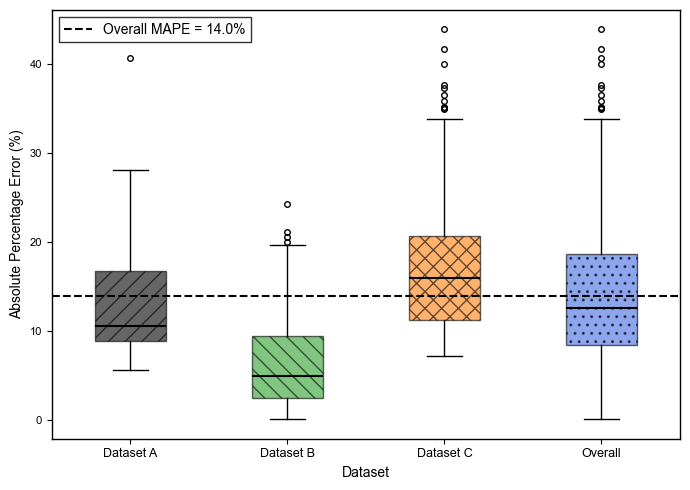

In [29]:
import matplotlib.pyplot as plt

# Updated color scheme
colors = {
    "Dataset A":    "black",
    "Dataset B":      "#2ca02c",
    "Dataset C": "#ff7f0e",
    "Overall":   "royalblue"   
}

# Hatching patterns for B/W compatibility
hatches = {
    "Dataset A":    "//",
    "Dataset B":      "\\\\",
    "Dataset C": "xx",
    "Overall":   ".."
}

data   = [all_pct_errors[name] for name in ["Dataset A", "Dataset B", "Dataset C", "Overall"]]
labels = ["Dataset A", "Dataset B", "Dataset C", "Overall"]

fig, ax = plt.subplots(figsize=(7, 5))

# Create boxplot
bp = ax.boxplot(
    data,
    labels       = labels,
    patch_artist = True,
    showfliers   = True,
    boxprops     = dict(linewidth=1.0),          
    medianprops  = dict(color="black", linewidth=1.5),
    whiskerprops = dict(linewidth=1.0),
    capprops     = dict(linewidth=1.0),
    flierprops   = dict(marker='o', markersize=4, markeredgecolor='black', 
                       markerfacecolor='none', linewidth=0.5)
)

# Fill boxes with colors and hatching
for patch, label in zip(bp["boxes"], labels):
    patch.set_facecolor(colors[label])
    patch.set_alpha(0.6)
    patch.set_edgecolor("black")
    patch.set_hatch(hatches[label])

# Standard spine styling
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.0)

# Axis labels
ax.set_ylabel("Absolute Percentage Error (%)", fontsize=10, fontname='Arial')
ax.set_xlabel("Dataset", fontsize=10, fontname='Arial')

# Set tick label fonts
ax.tick_params(axis='both', labelsize=8)
plt.setp(ax.get_xticklabels(), fontname='Arial', fontsize=9)
plt.setp(ax.get_yticklabels(), fontname='Arial', fontsize=8)

# Horizontal reference line at Overall MAPE
overall_mape = summary_df.loc[summary_df.Dataset=="Overall", "MAPE (%)"].values[0]
ax.axhline(overall_mape, color='k', linestyle='--', linewidth=1.5,
           label=f"Overall MAPE = {overall_mape:.1f}%")

# Legend
ax.legend(frameon=True, fancybox=False, edgecolor='black',
          fontsize=9, loc="upper left", prop={'family': 'Arial'})

plt.tight_layout()
plt.savefig(f"outputs/acs_plots/percent_error_box_acs.png",
            dpi=600, bbox_inches="tight", facecolor='white')
plt.show()
plt.close()


Saved heatmap to: acs_plots/heatmap_conductivity_ranges_clear.png


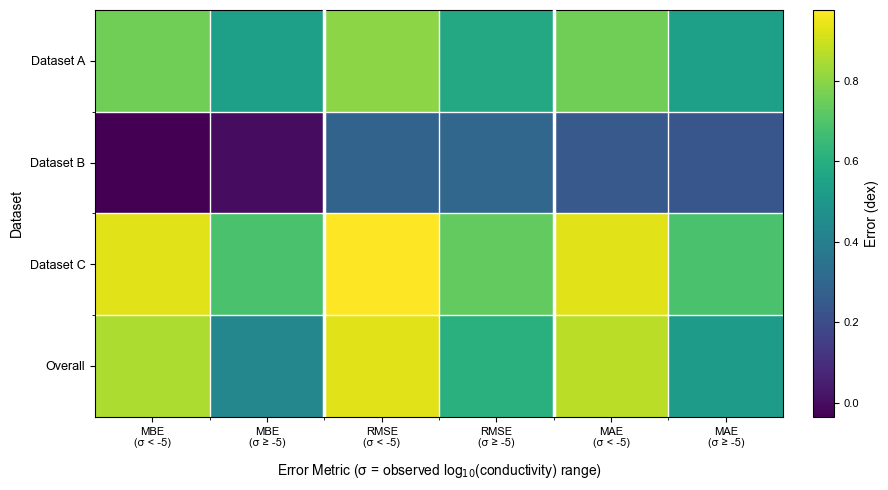

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your Excel file
df = pd.read_excel("docs/error_summaries/model_error_summary_threshold_-5_14sep.xlsx")

# Filter rows containing "true<-5" or "true>=-5"
mask = df["Dataset"].str.contains("true<-5|true>=-5", regex=True)
df_filtered = df[mask].copy()

# Extract base dataset name and range
df_filtered["Base"] = df_filtered["Dataset"].str.extract(r'^(.*?)\s*\(')[0]
df_filtered["Range"] = df_filtered["Dataset"].str.extract(r'true([<>]=?-5)')[0]
df_filtered["Range"] = df_filtered["Range"].replace({"<-5": "< -5", ">=-5": "≥ -5"})

# Select metrics
metrics = ["MBE (dex)", "RMSE (dex)", "MAE (dex)"]

# Create pivot tables for each metric and concatenate
heat_data = []
for m in metrics:
    pivot = df_filtered.pivot(index="Base", columns="Range", values=m)
    # Ensure column order
    if "< -5" in pivot.columns and "≥ -5" in pivot.columns:
        pivot = pivot[["< -5", "≥ -5"]]
    heat_data.append(pivot)

# Stack horizontally with metric names
heatmap_df = pd.concat(heat_data, axis=1, 
                       keys=metrics,
                       names=['Metric', 'Range'])

# Flatten column multi-index for display
heatmap_df.columns = [f"{metric}\n{range_val}" for metric, range_val in heatmap_df.columns]

# Reorder rows
row_order = ["Dataset A", "Dataset B", "Dataset C", "Overall"]
heatmap_df = heatmap_df.reindex([r for r in row_order if r in heatmap_df.index])

# Create figure with more width for better label spacing
fig, ax = plt.subplots(figsize=(9, 5))

# Create heatmap
im = ax.imshow(heatmap_df.values, cmap='viridis', aspect='auto')

# Set ticks
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_yticks(range(len(heatmap_df.index)))

# X-axis labels with better formatting
column_labels = []
for col in heatmap_df.columns:
    parts = col.split('\n')
    if len(parts) == 2:
        # Format: "MBE\n< -5" becomes "MBE\n(σ < -5)"
        metric = parts[0].replace(" (dex)", "")
        range_val = parts[1]
        column_labels.append(f"{metric}\n(σ {range_val})")
    else:
        column_labels.append(col)

ax.set_xticklabels(column_labels, rotation=0, ha='center', 
                   fontsize=8, fontname='Arial', linespacing=1.2)
ax.set_yticklabels(heatmap_df.index, fontsize=9, fontname='Arial')

# Grid lines
ax.set_xticks([x - 0.5 for x in range(1, len(heatmap_df.columns))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(heatmap_df.index))], minor=True)
ax.grid(which='minor', color='white', linewidth=1.0)

# Thicker lines to separate metric groups
for i in [1.5, 3.5]:
    ax.axvline(i, color='white', linewidth=2.5, zorder=10)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Error (dex)', fontsize=10, fontname='Arial')
cbar.ax.tick_params(labelsize=8)
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Arial')

# Clear axis labels
ax.set_xlabel('Error Metric (σ = observed log$_{10}$(conductivity) range)', 
              fontsize=10, fontname='Arial', labelpad=10)
ax.set_ylabel('Dataset', fontsize=10, fontname='Arial')

plt.tight_layout()

# Save
out_path = "outputs/acs_plots/heatmap_conductivity_ranges_clear.png"
plt.savefig(out_path, dpi=600, bbox_inches="tight", facecolor='white')
print(f"Saved heatmap to: {out_path}")
plt.show()
plt.close()


Saved distribution plot to 'distribution_plot_DDSE_test_acs.png' and '.pdf'
Shapiro-Wilk Test: W=0.9975, p-value=0.5516
Data is likely normally distributed (p > 0.05)


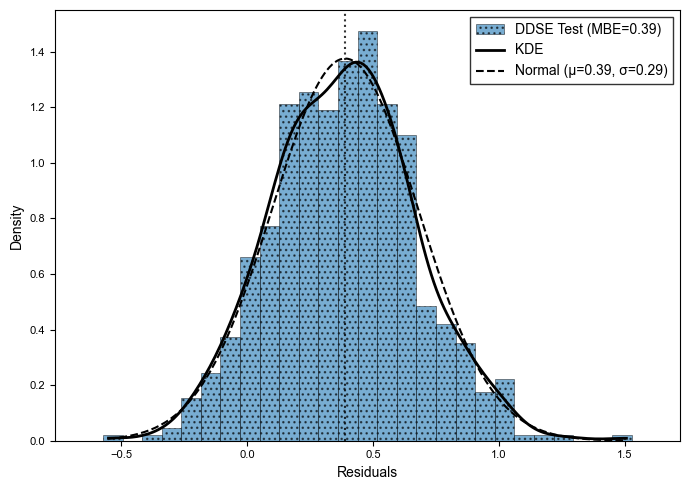

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Statistical parameters from your data
N = 583
R2 = 0.85
MTV = -4.38
MPV = -3.99
MAE = 0.50
RMSE = 0.56
MBE = 0.39
STD = 0.29

# Generate synthetic residuals based on MBE and STD
np.random.seed(42)
residuals = np.random.normal(loc=MBE, scale=STD, size=N)

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals)

# Create the distribution plot
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(residuals.min() - 0.1, residuals.max() + 0.1, 30)

# Histogram with hatch pattern
ax.hist(residuals, bins=bins, density=True,
        alpha=0.6,
        label=f"DDSE Test (MBE={MBE:.2f})",
        color='#1f77b4',  # Blue color
        edgecolor='black',
        linewidth=0.5,
        hatch='...')  # Vertical stripe pattern

# KDE overlay
kde = stats.gaussian_kde(residuals)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_range, kde(x_range), 'k-', linewidth=2, label='KDE')

# Normal distribution overlay for reference
normal_dist = stats.norm.pdf(x_range, MBE, STD)
ax.plot(x_range, normal_dist, 'k--', linewidth=1.5, 
        label=f'Normal (μ={MBE:.2f}, σ={STD:.2f})')

# Zero/MBE reference line
ax.axvline(MBE, color='k', linestyle=':', linewidth=1.5, alpha=0.8)

# Labels and formatting
ax.set_xlabel("Residuals", fontsize=10, fontname='Arial')
ax.set_ylabel("Density", fontsize=10, fontname='Arial')

# Add text box with statistics in corner (including Shapiro-Wilk test)
stats_text = f'N = {N}\n$R^2$ = {R2:.2f}\nMTV = {MTV:.2f}\nMPV = {MPV:.2f}\n'
stats_text += f'MAE = {MAE:.2f}\nRMSE = {RMSE:.2f}\nMBE = {MBE:.2f}\nSTD = {STD:.2f}\n'
stats_text += f'\nShapiro-Wilk:\nW = {shapiro_stat:.4f}\np = {shapiro_p:.4f}'

# ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
#         fontsize=8, verticalalignment='top', horizontalalignment='left',
#         bbox=dict(boxstyle='round', facecolor='white', 
#                  edgecolor='black', linewidth=1),
#         family='Arial')

# Legend with ACS-compatible font
ax.legend(frameon=True, fancybox=False, edgecolor='black',
          fontsize=9, loc='upper right', prop={'family': 'Arial'})

# Set tick label font
ax.tick_params(axis='both', which='major', labelsize=8)
plt.setp(ax.get_xticklabels(), fontname='Arial')
plt.setp(ax.get_yticklabels(), fontname='Arial')

# No grid
ax.grid(False)

plt.tight_layout()

# Save with high resolution
plt.savefig('outputs/misc_plots/distribution_plot_DDSE_test_acs.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('outputs/misc_plots/distribution_plot_DDSE_test_acs.pdf', bbox_inches='tight', facecolor='white')

print("Saved distribution plot to 'outputs/misc_plots/distribution_plot_DDSE_test_acs.png' and '.pdf'")
print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("Data is likely normally distributed (p > 0.05)")
else:
    print("Data is likely NOT normally distributed (p < 0.05)")
plt.show()
